In [278]:
# importing libraries 

import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt

In [279]:
# Reading libraries

words = open("names.txt", "r").read().splitlines()
len(words)

32033

In [280]:
# Mapping functions

chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}

stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [296]:
# Defining the constants

block_size = 3
hidden_layers = 300
dimensions = 20
vocab_size = len(itos)

In [297]:
# Building the dataset

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# Traning validation and testing split

Xtr, Ytr = build_dataset(words[:n1])
Xva, Yva = build_dataset(words[n1: n2])
Xte, Yte = build_dataset(words[n2:])

print(Xtr.shape, Ytr.shape)
print(Xte.shape, Yte.shape)
print(Xte.shape, Yte.shape)

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22928, 3]) torch.Size([22928])
torch.Size([22928, 3]) torch.Size([22928])


In [298]:
# Multi Level Perceptron Parameters

g = torch.Generator().manual_seed(34)
C = torch.randn((vocab_size, dimensions),generator=g, requires_grad=True)
w1 = (torch.randn((dimensions*block_size, hidden_layers), generator=g) * 0.1).requires_grad_()
b1 = (torch.randn((hidden_layers), generator=g) * 0.01).requires_grad_()
w2 = (torch.randn((hidden_layers, vocab_size), generator=g) * 0.01).requires_grad_()
# b2 = (torch.randn(vocab_size, generator=g, requires_grad=True) * 0)
b2 = torch.zeros(vocab_size, requires_grad=True)

parameters = [C, w1, b1, w2, b2]

print(sum(p.nelement() for p in parameters))

26967


In [308]:
# Training loop with optimised steps

epochs = 100000
batch_size = 32
lossi = []

for i in range(epochs):
    # Minbatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ w1 + b1
    h = torch.tanh(hpreact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update learning rate
    lr = 0.01 if i < 10000 else 0.01
    for p in parameters  :
        p.data += -lr * p.grad

    # Track stats
    if i % 1000 == 0:
        print(loss)
    lossi.append(loss.log10().item())

tensor(3.2709, grad_fn=<NllLossBackward0>)
tensor(2.2480, grad_fn=<NllLossBackward0>)
tensor(2.4350, grad_fn=<NllLossBackward0>)
tensor(2.2967, grad_fn=<NllLossBackward0>)
tensor(2.4985, grad_fn=<NllLossBackward0>)
tensor(2.5008, grad_fn=<NllLossBackward0>)
tensor(2.4404, grad_fn=<NllLossBackward0>)
tensor(2.3741, grad_fn=<NllLossBackward0>)
tensor(2.0886, grad_fn=<NllLossBackward0>)
tensor(2.2345, grad_fn=<NllLossBackward0>)
tensor(2.4170, grad_fn=<NllLossBackward0>)
tensor(1.9316, grad_fn=<NllLossBackward0>)
tensor(2.3565, grad_fn=<NllLossBackward0>)
tensor(2.0718, grad_fn=<NllLossBackward0>)
tensor(2.3634, grad_fn=<NllLossBackward0>)
tensor(2.4502, grad_fn=<NllLossBackward0>)
tensor(2.0252, grad_fn=<NllLossBackward0>)
tensor(2.0241, grad_fn=<NllLossBackward0>)
tensor(2.3704, grad_fn=<NllLossBackward0>)
tensor(2.3686, grad_fn=<NllLossBackward0>)
tensor(1.9845, grad_fn=<NllLossBackward0>)
tensor(2.2168, grad_fn=<NllLossBackward0>)
tensor(2.1413, grad_fn=<NllLossBackward0>)
tensor(2.29

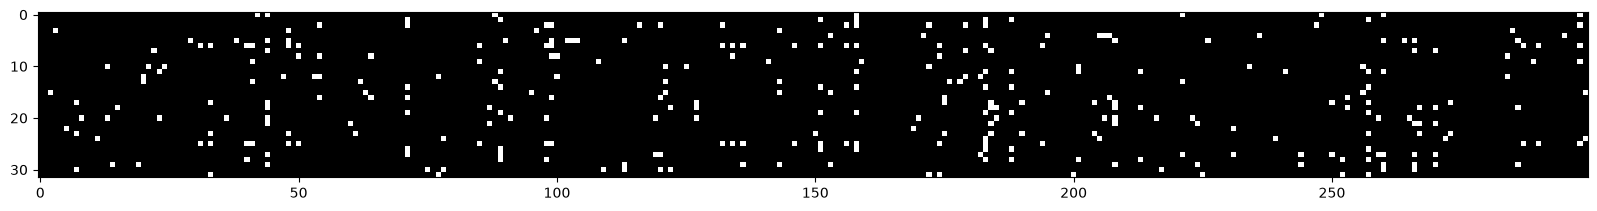

In [309]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='grey', interpolation='nearest')

(array([523., 349., 315., 244., 238., 200., 222., 162., 141., 187., 162.,
        161., 171., 154., 172., 143., 129., 152., 148., 133., 133., 134.,
        120., 110., 113., 114., 118., 141., 134., 133., 114., 127., 138.,
        133., 166., 167., 141., 135., 206., 171., 165., 191., 187., 220.,
        237., 273., 235., 292., 396., 550.]),
 array([-9.99924541e-01, -9.59927070e-01, -9.19929600e-01, -8.79932129e-01,
        -8.39934659e-01, -7.99937189e-01, -7.59939718e-01, -7.19942248e-01,
        -6.79944777e-01, -6.39947307e-01, -5.99949837e-01, -5.59952366e-01,
        -5.19954896e-01, -4.79957426e-01, -4.39959955e-01, -3.99962485e-01,
        -3.59965014e-01, -3.19967544e-01, -2.79970074e-01, -2.39972603e-01,
        -1.99975133e-01, -1.59977663e-01, -1.19980192e-01, -7.99827218e-02,
        -3.99852514e-02,  1.22189522e-05,  4.00096893e-02,  8.00071597e-02,
         1.20004630e-01,  1.60002100e-01,  1.99999571e-01,  2.39997041e-01,
         2.79994512e-01,  3.19991982e-01,  3.59989

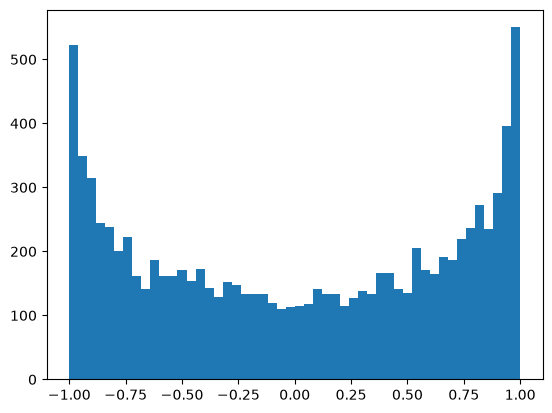

In [311]:
plt.hist(h.view(-1).tolist(),50)

In [286]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train' : (Xtr, Ytr),
        'test' : (Xte, Yte), 
        'val' : (Xva, Yva)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss)

split_loss('train')
split_loss('val')
split_loss('test')

train tensor(3.2934)
val tensor(3.2936)
test tensor(3.2933)


In [287]:
# Sampling from the model
max_len = 20
for _ in range(10):
    out = []
    context = [0]*block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, block_size*dimensions) @ w1 + b1)
        o = h @ w2 + b2
        probs = F.softmax(o, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0 or len(out) >= max_len:
            break

    print(''.join(itos[i] for i in out))

whttcqrgmybirocrgzlz
bztjkcftsempxqyqwrsp
szkmtxhjrvmbnwbrubvf
mkdugqnabshsxozgutcm
aarptcnhwvdhyvsxplnj
tetzisbsnxcx.
ykddim.
svffsljzagmnjdiafysh
kycpskiuswghiiiwokif
teaqtwrbfiotozzvvzbh
